In [55]:
import matplotlib.pylab as plt
import numpy as np
import cv2
from glob import glob
import os
import pandas as pd
import matplotlib

import torch
from torch.utils.data import Dataset
from torchvision.io import read_image
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

from sklearn.model_selection import train_test_split

In [7]:
print(torch.__version__)
device_name = torch.cuda.current_device()
print(f'GPU: {device_name}')
device = "cuda"

2.6.0+cu124
GPU: 0


## Flowers dataset

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("batoolabbas91/flower-photos-by-the-tensorflow-team")

print("Path to dataset files:", path)

100%|██████████| 219M/219M [00:01<00:00, 161MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/batoolabbas91/flower-photos-by-the-tensorflow-team/versions/1


In [11]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3

def read_img(filename, shape):
    img = cv2.imread(filename)
    img = img[..., ::-1]
    img = cv2.resize(img, shape)
    return img.astype(float) / 255

CLASS_NAMES = glob("/root/.cache/kagglehub/datasets/batoolabbas91/flower-photos-by-the-tensorflow-team/versions/1/flower_photos/*")
CLASS_NAMES = [os.path.basename(x) for x in CLASS_NAMES]
CLASS_NAMES = [x for x in CLASS_NAMES  if not '.' in x]
print("These are the available classes:", CLASS_NAMES)

These are the available classes: ['dandelion', 'tulips', 'daisy', 'roses', 'sunflowers']


In [12]:
# Set seed for reproducibility
np.random.seed(0)
torch.manual_seed(0);

In [15]:
# split dataset to train / val
data_dir = "/root/.cache/kagglehub/datasets/batoolabbas91/flower-photos-by-the-tensorflow-team/versions/1/"

X = glob(os.path.join(data_dir, "flower_photos/*/*.jpg"))
y = [filename.split('/')[-2] for filename in X]

X_train, X_val, y_train, y_val = train_test_split(X, y,
                                                    stratify=y,
                                                    test_size=0.10)

# save splits
train_df = pd.DataFrame({"path": X_train, "flower": y_train})
val_df = pd.DataFrame({"path": X_val, "flower": y_val})

train_df.to_csv("flowers_train.csv", index=False)
val_df.to_csv("flowers_val.csv", index=False)

In [16]:
class FlowersDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = self.img_labels.iloc[idx, 0]
        image = read_img(img_path, [IMG_HEIGHT, IMG_WIDTH])
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image.transpose(2, 0, 1), label

train_dataset = FlowersDataset("flowers_train.csv", data_dir)
val_dataset = FlowersDataset("flowers_val.csv", data_dir)

# decode_csv changed so that the label is the index into CLASS_NAMES array
def idx_label(label):
  label = np.argmax(np.equal(CLASS_NAMES, label))
  return label

train_dataset.img_labels["flower"] = train_dataset.img_labels["flower"].map(idx_label)
val_dataset.img_labels["flower"] = val_dataset.img_labels["flower"].map(idx_label)

In [27]:
preprocess = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

BATCH_SIZE = 32

trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE,
                                          shuffle=False, num_workers=2)

## Transfer Learning with MobileNet

In [52]:
class CustomModel(nn.Module):
    def __init__(self) -> None:
        super(CustomModel, self).__init__()
        self.mobilenet = torchvision.models.mobilenet_v2(weights='DEFAULT')
        for param in self.mobilenet.features.parameters():
            param.requires_grad = False
        self.pool = torch.nn.functional.adaptive_avg_pool2d
        self.linear1 = torch.nn.Linear(1280, 5)

    def forward(self, x):
        x = self.mobilenet.features(x)
        x = self.pool(x, (1, 1))
        return torch.flatten(x, 1)

In [53]:
model = CustomModel()

In [54]:
images = next(iter(trainloader))[0].float()
logits = model(images)
logits.shape

torch.Size([32, 1280])

In [21]:
## compute accuracy
def get_accuracy(inputs, target, batch_size):
    ''' Obtain accuracy for training round '''
    accuracy = torch.sum(inputs == target) / batch_size
    return accuracy.item()

In [50]:
s = torch.nn.Softmax(dim=1)

In [51]:
def train_loop(model,
               trainloader,
               valloader,
               criterion,
               optimizer,
               num_epochs=10,
               batch_size=32,
               l1=0,
               l2=0
               ):
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_accuracy': [],
        'val_accuracy': []
    }

    model = model.to(dtype=torch.float64)

    for epoch in range(num_epochs):
        train_loss = 0.0
        train_accuracy = 0.0
        val_loss = 0.0
        val_accuracy = 0.0

        model = model.train()

        ## training step
        for i, (images, labels) in enumerate(trainloader):
            images = preprocess(images)
            images = images.to(device)
            labels = labels.to(device)

            ## forward + backprop + loss
            logits = model(images)
            loss = criterion(logits, labels)

            # Apply L1 regularization
            if l1 > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss += l1 * l1_norm

            # Apply L2 regularization
            elif l2 > 0:
                l2_norm = sum(p.pow(2).sum() for p in model.parameters())
                loss += l2 * l2_norm

            optimizer.zero_grad()
            loss.backward()

            ## update model params
            optimizer.step()

            train_loss += loss.detach().item()

            probs = s(logits)
            inputs = torch.argmax(probs, dim=1)
            train_accuracy += get_accuracy(inputs, labels, batch_size)

        history['train_loss'].append(train_loss / len(trainloader))
        history['train_accuracy'].append(train_accuracy/len(trainloader))
        print('Epoch: %d | Loss: %.4f | Train Accuracy: %.2f' \
            %(epoch, train_loss / len(trainloader), train_accuracy / len(trainloader)))

        ## validation step
        model.eval()
        for i, (images, labels) in enumerate(valloader):

            images = preprocess(images)
            images = images.to(device)
            labels = labels.to(device)

            with torch.no_grad():
                ## forward + loss
                logits = model(images)
                loss = criterion(logits, labels)

                val_loss += loss.detach().item()

                probs = s(logits)
                inputs = torch.argmax(probs, dim=1)
                val_accuracy += get_accuracy(inputs, labels, batch_size)

        history['val_loss'].append(val_loss / len(valloader))
        history['val_accuracy'].append(val_accuracy/len(valloader))

    return history

In [67]:
matplotlib.rcParams.update({'font.size': 15})

def training_plot(history):
    f, ax = plt.subplots(1, 2, figsize=(10,4))
    ax[0].plot(history['train_loss'])
    ax[0].plot(history['val_loss'], ls='dashed')
    ax[1].plot(history['train_accuracy'])
    ax[1].plot(history['val_accuracy'], ls='dashed')
    ax[0].set_xlabel("Epochs")
    ax[1].set_xlabel("Epochs")
    ax[0].legend(['train_loss', 'val_loss'], fontsize=15)
    ax[1].legend(['train_accuracy', 'val_accuracy'], fontsize=15)

def plot_predictions(model, dataset):
    matplotlib.rcParams.update({'font.size': 10})
    f, ax = plt.subplots(3, 5, figsize=(16, 10))
    for idx, (img, label) in enumerate(dataset):
        if idx > 14:
            break
        ax[idx//5, idx%5].imshow((img.transpose(1, 2, 0)));
        batch_img = torch.unsqueeze(torch.Tensor(img), 0)
        batch_img = batch_img.to(torch.float64).to(device)
        batch_img
        with torch.no_grad():
            ## forward + loss
            logits = model(batch_img)
            probs = s(logits)
            preds = torch.argmax(probs, dim=1)
        label = CLASS_NAMES[label]
        pred_label = CLASS_NAMES[preds[0]]
        ax[idx//5, idx%5].set_title('{} -> {} ({:.2f})'.format(label, pred_label, torch.max(probs)))
        ax[idx//5, idx%5].axis('off')

In [57]:
def train_and_evaluate(trainloader,
                       valloader,
                       num_epochs=10,
                       batch_size = 32,
                       lrate = 1e-3, # default in Adam constructor
                       l1 = 0,
                       l2 = 0,
                       num_hidden = 16
                       ):


    model = torch.nn.Sequential(
        CustomModel(),
        torch.nn.Linear(in_features=1280,
                        out_features=num_hidden),
        torch.nn.ReLU(),
        torch.nn.Linear(in_features=num_hidden, out_features=5)
    )
    model = model.to(device)

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lrate)

    history = train_loop(model, trainloader, valloader, criterion, optimizer, num_epochs, l1=l1, l2=l2)
    training_plot(history)
    return model

Epoch: 0 | Loss: 0.9242 | Train Accuracy: 0.71
Epoch: 1 | Loss: 0.4297 | Train Accuracy: 0.87
Epoch: 2 | Loss: 0.3271 | Train Accuracy: 0.89
Epoch: 3 | Loss: 0.2839 | Train Accuracy: 0.90
Epoch: 4 | Loss: 0.2537 | Train Accuracy: 0.91
Epoch: 5 | Loss: 0.2293 | Train Accuracy: 0.92
Epoch: 6 | Loss: 0.2115 | Train Accuracy: 0.92
Epoch: 7 | Loss: 0.2070 | Train Accuracy: 0.92
Epoch: 8 | Loss: 0.1835 | Train Accuracy: 0.93
Epoch: 9 | Loss: 0.1814 | Train Accuracy: 0.93


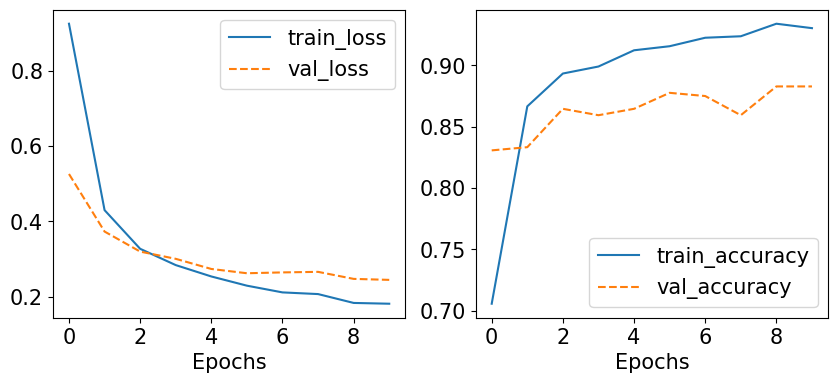

In [58]:
model = train_and_evaluate(trainloader, valloader)

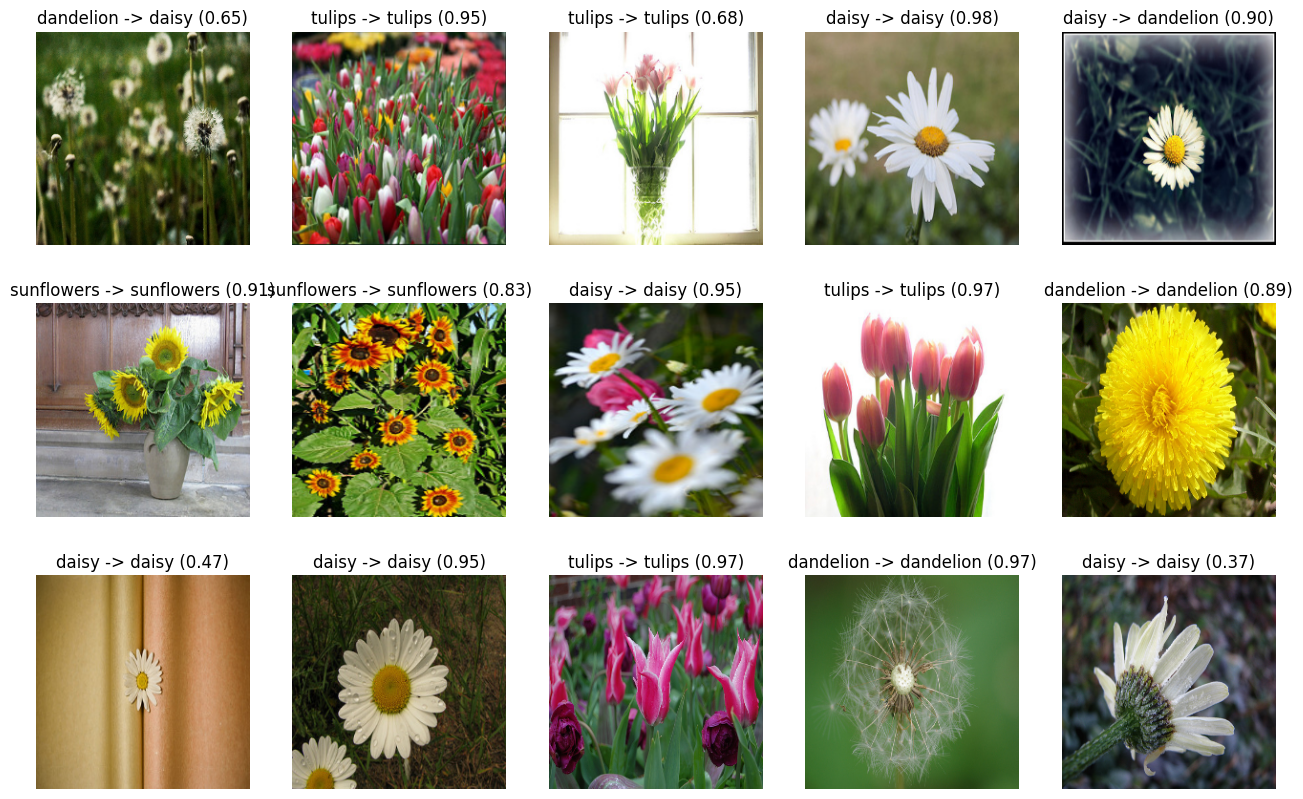

In [68]:
plot_predictions(model, val_dataset)